# **A. Root finding for scalar nonlinear equations**

In [1]:
# import all the packages here
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Function that finds the fixed point of a certain function phi
#
# Possible usages:
# x, success, errEst, xHist = fpIterator(phi, x0, tol, maxit)
# x, success, errEst, xHist = fpIterator(phi, x0, tol)
# x, success, errEst, xHist = fpIterator(phi, x0)
# x, success, errEst, _ = fpIterator(phi, x0, tol, maxit)
# x, success, errEst, _ = fpIterator(phi, x0, tol)
# x, success, errEst, _ = fpIterator(phi, x0)
#
# INPUT:
# phi           iteration function (function handle)
# x0            initial guess for the root
# tol           desired tolerance to stop iterations
# maxit         maximum number of iterations
#
# OUTPUT:
# x             solution at the final iteration
# success       true means converged according to error estimator
# errEst        array with error estimate per iterations
# xHist         array with solutions per iterations


def fpIterator(phi, x0, tol=1e-8, maxit=20):

    # initialize your output variables here (x, success, errEst, xHist)
    x = x0
    success = False
    errEst = np.empty(maxit)
    xHist = np.empty((maxit + 1, len(x0)))
    xHist[0,:] = x0

    # loop (at most maxit iterations) to find the root
    for i in range(maxit):
        # compute new guess for the root
        xNew = phi(xHist[i,:])
        # update array with solutions per iterations
        xHist[i+1,:] = xNew

        # compute error at current iteration
        error = np.linalg.norm(xNew - x)
        # update array with error estimate per iterations
        errEst[i] = error

        # checking for convergence, i.e. check if the error at the current iteration reached the tolerance
        if error < tol:
            # final x value
            x = xHist[i+1,:]
            # update success
            success = True
            # cut xHist up to and including the (i+1)st elements (since first entry is x0)
            xHist = xHist[:i+2,:]
            # cut errEst up to and including the ith element
            errEst = errEst[:i+1]
            break

        # update the previous iteration of x
        x = xNew

    return x, success, errEst, xHist


In [3]:
phi = lambda x: - ( 1 / ((x ** 2) -2) )

# looping through all initial conditions
for x0 in [(i * 0.25) for i in range(-8, 9)]:
   x, success, errEst, xHist = fpIterator(phi, [x0], tol=1e-6, maxit=20)

   print(f"Initial guess: \n x0 = {x0}")
   print(f"Final solution: {x}")
   print(f"Success: {success}")
   print(f"Error estimates:\n {errEst}")
   print(f"Intermediate solutions: \n {xHist}")
   print()

Initial guess: 
 x0 = -2.0
Final solution: [0.61803346]
Success: True
Error estimates:
 [1.50000000e+00 1.07142857e+00 2.61324042e-02 1.11110620e-02
 5.00623092e-03 2.31324717e-03 1.08123885e-03 5.08086368e-04
 2.39352838e-04 1.12888600e-04 5.32723913e-05 2.51459355e-05
 1.18709909e-05 5.60442977e-06 2.64598775e-06 1.24925145e-06
 5.89813295e-07]
Intermediate solutions: 
 [[-2.        ]
 [-0.5       ]
 [ 0.57142857]
 [ 0.59756098]
 [ 0.60867204]
 [ 0.61367827]
 [ 0.61599152]
 [ 0.61707275]
 [ 0.61758084]
 [ 0.61782019]
 [ 0.61793308]
 [ 0.61798635]
 [ 0.6180115 ]
 [ 0.61802337]
 [ 0.61802898]
 [ 0.61803162]
 [ 0.61803287]
 [ 0.61803346]]

Initial guess: 
 x0 = -1.75
Final solution: [0.61803562]
Success: False
Error estimates:
 [8.08823529e-01 1.83869200e+00 6.03212479e-02 6.74339971e-02
 5.92651146e-02 4.16868060e-02 2.47670285e-02 1.32103901e-02
 6.63160441e-03 3.22603483e-03 1.54512107e-03 7.34499386e-04
 3.47905996e-04 1.64510154e-04 7.77272676e-05 3.67103565e-05
 1.73350710e-05 8.1

In [4]:
## Discussion question A.1(a)

# after defining phi, x0, tol and maxit as written in the pdf, you set up
# your output as follows

print('FP iteration results:\n')
print('----------------------------------------------------')

# looping through all initial conditions
for x0 in [(i * 0.25) for i in range(-8, 9)]:
    x, success, errEst, xHist = fpIterator(phi, [x0], tol=1e-6, maxit=20)

    #compute no. of iterations given by the length of the error array
    nIterations = len(errEst)

    if success:
        print('x0 = %4.2f converged to %4.6f in %d iterations.' % (x0, x, nIterations))
    else:
        print('x0 = %4.2f failed to converge. Iterations: %d' % (x0, nIterations))


FP iteration results:

----------------------------------------------------
x0 = -2.00 converged to 0.618033 in 17 iterations.
x0 = -1.75 failed to converge. Iterations: 20
x0 = -1.50 converged to 0.618033 in 19 iterations.
x0 = -1.25 converged to 0.618034 in 19 iterations.
x0 = -1.00 converged to 1.000000 in 2 iterations.
x0 = -0.75 converged to 0.618035 in 17 iterations.
x0 = -0.50 converged to 0.618033 in 16 iterations.
x0 = -0.25 converged to 0.618034 in 17 iterations.
x0 = 0.00 converged to 0.618033 in 17 iterations.
x0 = 0.25 converged to 0.618034 in 17 iterations.
x0 = 0.50 converged to 0.618033 in 16 iterations.
x0 = 0.75 converged to 0.618035 in 17 iterations.
x0 = 1.00 converged to 1.000000 in 1 iterations.
x0 = 1.25 converged to 0.618034 in 19 iterations.
x0 = 1.50 converged to 0.618033 in 19 iterations.
x0 = 1.75 failed to converge. Iterations: 20
x0 = 2.00 converged to 0.618033 in 17 iterations.


<ipython-input-4-25b58b83bebc>:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('x0 = %4.2f converged to %4.6f in %d iterations.' % (x0, x, nIterations))


In [5]:
# Function that finds the solution of an equation or system of equations
# using the Newton method

# Possible usages:
# x, success, errEst, xHist = newton(phi, x0, tol, maxit)
# x, success, errEst, xHist = newton(phi, x0, tol)
# x, success, errEst, xHist = newton(phi, x0)
# x, success, errEst, _ = newton(phi, x0, tol, maxit)
# x, success, errEst, _ = newton(phi, x0, tol)
# x, success, errEst, _ = newton(phi, x0)
#
# INPUT:
# f             function handling (may be vector valued)
# df            derivative of f (or function returning Jacobian matrix)
# x0            initial guess
# tol           desired toleraance to stop iterations
# maxit         maximum number of iterations
#
# OUTPUT:
# x             solution at the final iteration
# success       true means converged according to error estimator
# errEst        array with error estimate per iterations
# xHist         array with solutions per iterations
#


def newton(f, df, x0, tol=1e-8, maxit=20):

    # implementation should be trivial using your fpIterator with a properly
    # implemented function phi

    if len(x0) == 1:
      # define Newton phi
      phiN = lambda x: x - ( f(x) / df(x) )
    else:
      invdf = lambda x: np.linalg.inv(df(x))
      phiN = lambda x: x - ( np.linalg.solve(df(x), f(x)) )

    # use fpIterator with phiN as input
    x, success, errEst, xHist = fpIterator(phiN, x0, tol, maxit)


    return x, success, errEst, xHist

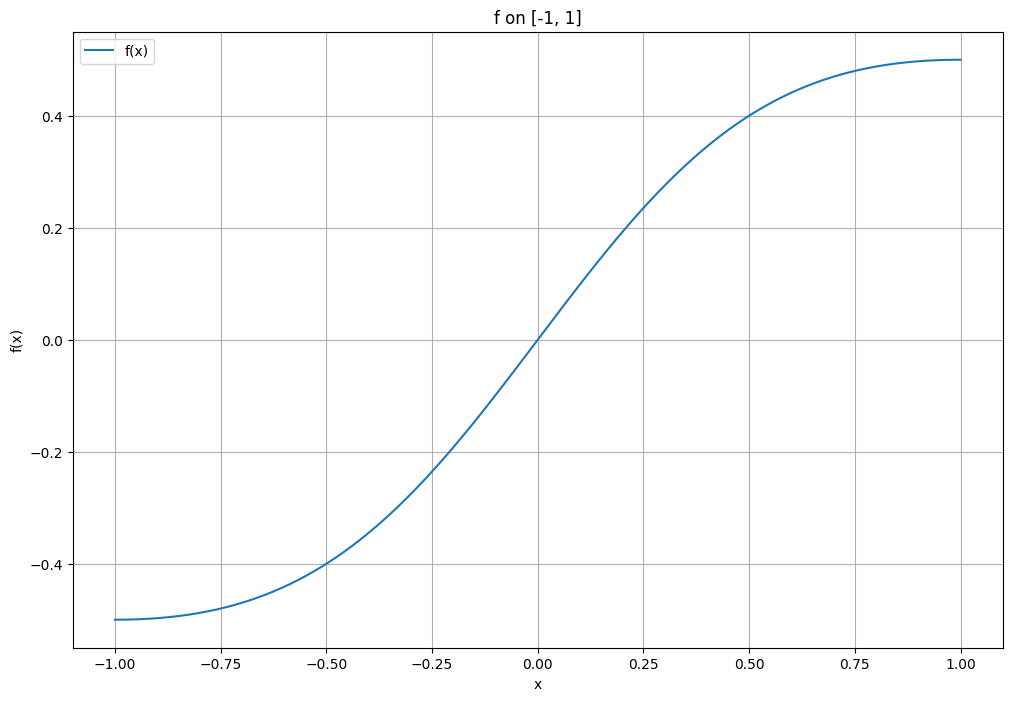

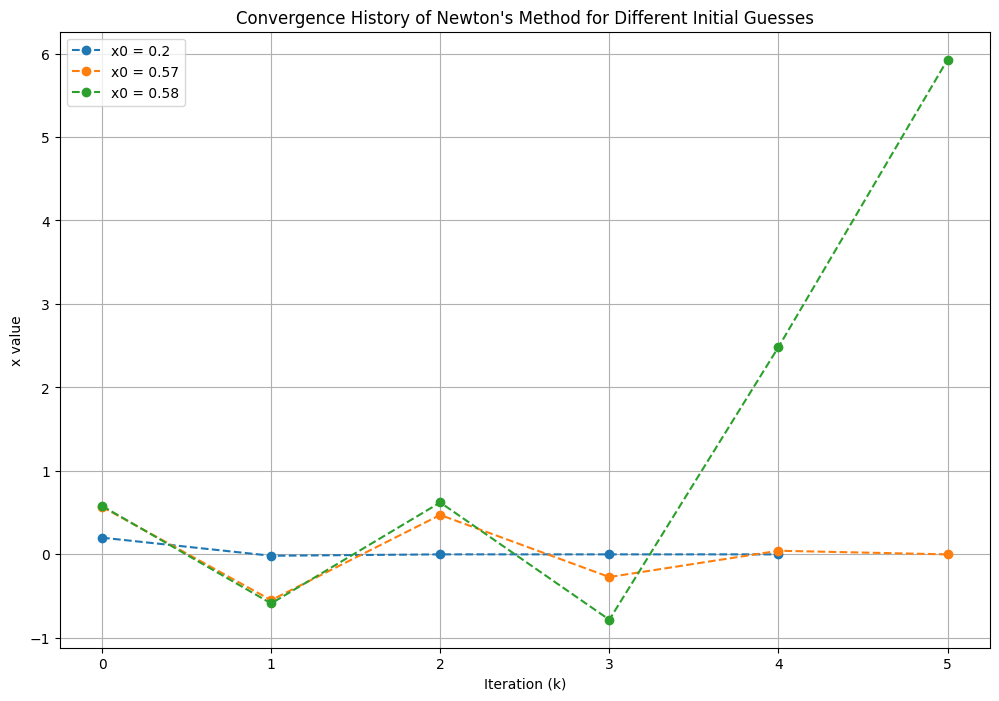

In [6]:
## Discussion question A.2

# set up inputs and initial guesses
f = lambda x: x / ( 1 + (x ** 2) )
df = lambda x: - ( ( (x ** 2) - 1 ) / ( (x ** 2) + 1 ) ** 2 )
initialGuesses = [0.2, 0.57, 0.58]

#plot the function on [-1, 1]
plt.figure(figsize=(12, 8))
plt.plot(np.linspace(-1, 1, int(1e3 + 1)), f(np.linspace(-1, 1, int(1e3 + 1))), label = 'f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('f on [-1, 1]')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 8))

x0 = np.empty((1))
# then for all the initial guesses, find the root using newton() and plot xHist

for x0 in initialGuesses:
    x, success, errEst, xHist = newton(f, df, [x0], tol=1e-8, maxit=20)
    # >>>cut xHist to improve plot readability
    plt.plot(range(len(xHist[:6])), xHist[:6], marker='o', linestyle = 'dashed', label=f'x0 = {x0}')

plt.xlabel('Iteration (k)')
plt.ylabel('x value')
plt.title('Convergence History of Newton\'s Method for Different Initial Guesses')
plt.legend()
plt.grid(True)
plt.show()

# **B. Root finding for systems of nonlinear equations**

In [7]:
## Discussion question B.1

# - set the correct inputs and find the root
# - compute the order
# - compute the factor
# - print out in a readable way, you can use the following code or something similar

# setting up inputs
phi = lambda x: - ( 1 / ((x ** 2) - 2) )
g = lambda x: (x ** 3) - (2 * x) + 1
dg = lambda x: (3 * (x ** 2) ) - 2
x0 = 1/4

xFp, successFp, errEstFp, xHistFp = fpIterator(phi, [x0], tol=1e-12, maxit=20)

xNewton, successNewton, errEstNewton, xHistNewton = newton(g, dg, [x0], tol=1e-12, maxit=20)


def order(x, xHist):
    # compute error of iterand using (5)
    ek = np.zeros(xHist.shape[0])
    for k in range(xHist.shape[0]):
        ek[k] = np.linalg.norm(xHist[k,:] - x)

    # Calculate the order using(5)
    p = np.log(ek[-2] / ek[-3]) / np.log(ek[-3] / ek[-4])
    return p
    # if we print int(p), we get 2 as expected

def convFact(x, xHist):
    # Compute the convergence factor using the fact that order of convergence = 2
    c =   np.abs( ( (xHist[-2,:]) - x ) / ( (xHist[-3,:] - x ) ** 2) )
    return c[0]


print('\n\nConvergence order results: \n')
print('    method                   order                   factor')
print('-------------------------------------------------------------------')
#print('Fixed point iteration     ', order(xFp, xHistFp),   convFact(xFp, xHistFp))
print('Newton method             ', order(xNewton, xHistNewton),   convFact(xNewton, xHistNewton))




Convergence order results: 

    method                   order                   factor
-------------------------------------------------------------------
Newton method              2.0001137575431107 2.1663679722217357


In [8]:
## Discussion question B.2

x0 = np.array([0, 0])

# setup your matrix and vector defining the linear system
A = np.array([[2, -1], [-1, 2]])
b = np.array([1, 0])

# then define F(x) and J(x)
F = lambda x: b - np.matmul(A, x)
J = lambda x: - A



x, success, errEst, xHist = newton(F, J, x0, 1e-8, 20)
print( f"x: {x} \nsuccess: {success} \nerrEst: {errEst} \nxHist:\n {xHist}\n")
nIterations = len(errEst)
print("Number of iterations:", nIterations)



x: [0.66666667 0.33333333] 
success: True 
errEst: [0.74535599 0.        ] 
xHist:
 [[0.         0.        ]
 [0.66666667 0.33333333]
 [0.66666667 0.33333333]]

Number of iterations: 2


In [9]:
## THIS FUNCTION IS GIVEN TO THE STUDENTS

# plotResidual_partB
#
# INPUT
# p         parameter which shifts the parabola

def plotResidual_partB(p):

    plt.figure(figsize=(18,10))

    nHat = np.array([0.5, 1])
    nHat = nHat/np.linalg.norm(nHat)
    tHat = np.array([nHat[1], -nHat[0]])
    xHat = np.array([[2],[1]])/np.sqrt(2)

    # For plotting the curves we parametrize them using angle (F1) and tangential co-ordinate (F2)
    par1 = lambda theta, p:  np.array([[2*np.cos(theta)], [np.sin(theta)]])
    par2 = lambda t, p: np.outer((tHat), t) + np.outer( (nHat), (np.matmul(nHat,xHat) + (p+0.5*np.power(t-np.matmul(tHat,xHat), 2)) ) )
    parametrizations = [par1, par2]

    paramRanges = [[0, 2*np.pi], [-1, 2.5]]
    paramStyles = ['r-','r--']

    N = 100
    xLim = [-5, 5]
    yLim = [-2.5, 3.5]

    # Plot contours of the error
    xVals = np.linspace(xLim[0], xLim[1], N)
    yVals = np.linspace(yLim[0], yLim[1], N)
    X, Y = np.array( np.meshgrid(xVals, yVals, indexing='xy') )

    s1 = lambda x,y: np.power( np.power(x/2, 2) + np.power(y, 2) - 1, 2)
    s2 = lambda x,y: np.power( nHat[0]*x + nHat[1]*y -np.matmul(nHat, xHat) - (p+0.5*np.power( (tHat[0]*x+tHat[1]*y-np.matmul(tHat, xHat)),2 )) ,2 )
    errFun = lambda x, y: np.sqrt(s1(x,y) + s2(x,y))
    Z = np.log10(errFun(X, Y))

    levels = np.arange(-2, 1, 0.25)
    plt.contourf( xVals, yVals, Z, levels )

    # Add parametrized curves
    i = 0
    for pdx in parametrizations:
        params = np.linspace(paramRanges[i][0], paramRanges[i][1], N)
        xyCoords = pdx(params, p)

        if i == 1:
            x = xyCoords[0, :]
            y = xyCoords[1, :]
        else:
            x = xyCoords[0, :][0]
            y = xyCoords[1, :][0]

        plt.plot(x, y, paramStyles[i])

        i += 1

    plt.colorbar()
    plt.xlabel('$x_1$', fontsize=16)
    plt.ylabel('$x_2$', fontsize=16)
    plt.title('Colormap corresponds to $\log_{{10}}\sqrt{{F_1^2 + F_2^2}}$, where $p = %4.2f $' % p, fontsize=16)


EXPLORE THE CONVERGENCE OF THE METHOD

    p            x0                        success      iter            order                   x 

------------------------------------------------------------------------------------------------------------------
-0.5         [0.519786,3.390388]            True         6            1.997256             [0.59554 ,0.954638]
0.0          [0.519786,3.390388]            True         22           1.296653             [1.414213,0.707107]
0.5          [0.519786,3.390388]            False        1000         0.768691             [-6.217618, 4.359671]
-0.5         [4.097495,1.601534]            True         6            2.042116             [1.969855,0.172967]
0.0          [4.097495,1.601534]            True         22           1.296624             [1.414214,0.707107]
0.5          [4.097495,1.601534]            False        1000         0.044320             [ 5.29346,-0.89484]


<Figure size 1200x800 with 0 Axes>

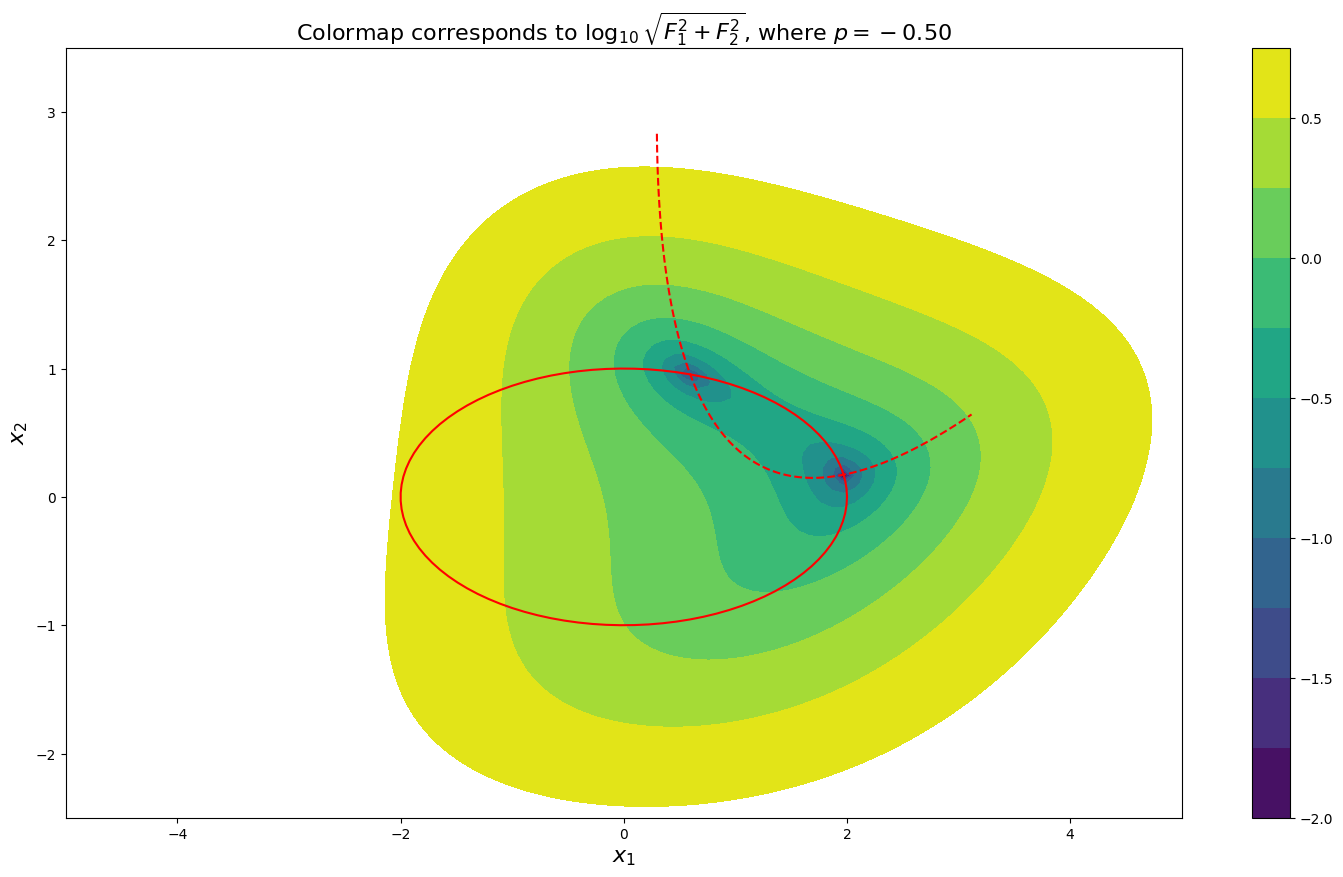

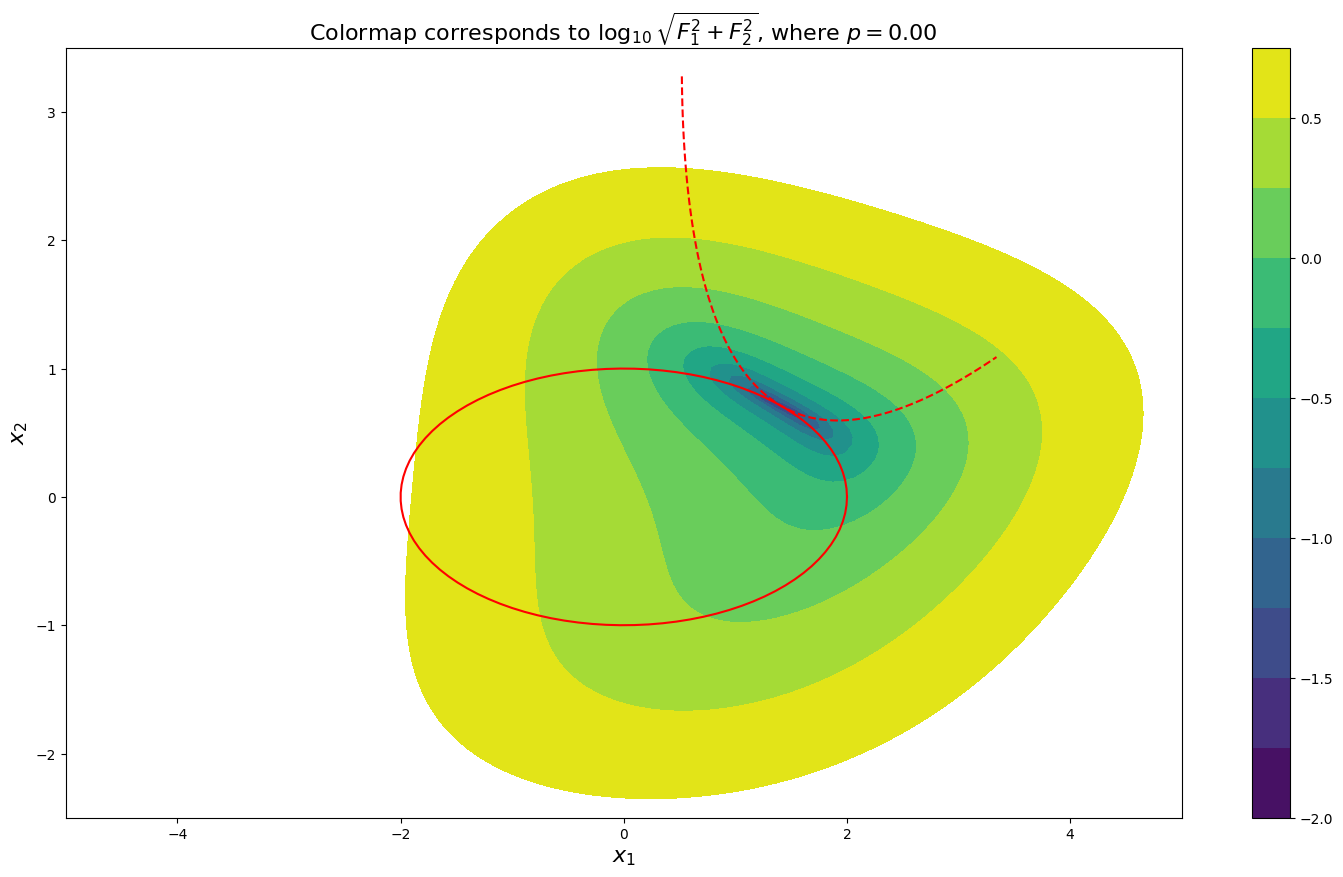

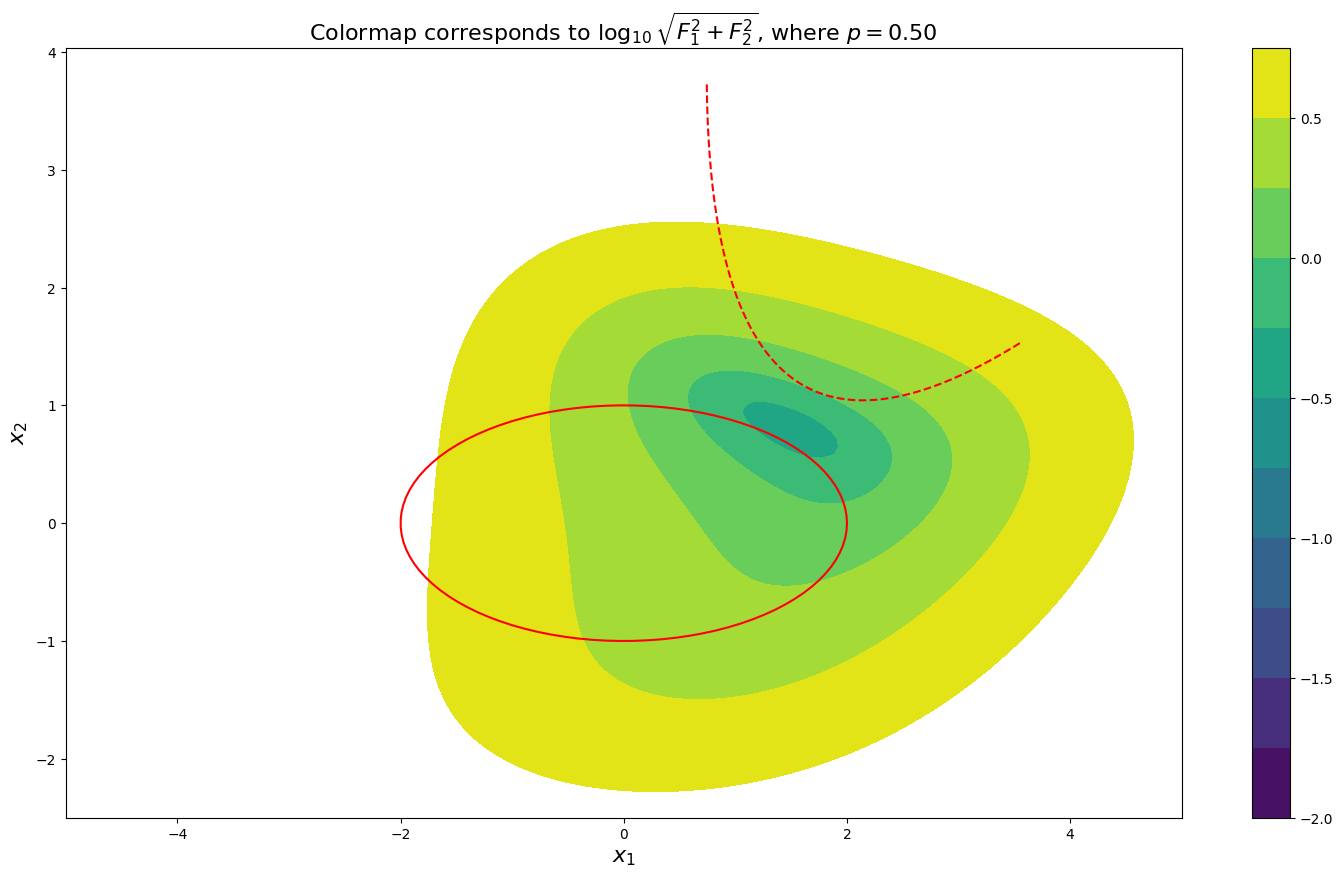

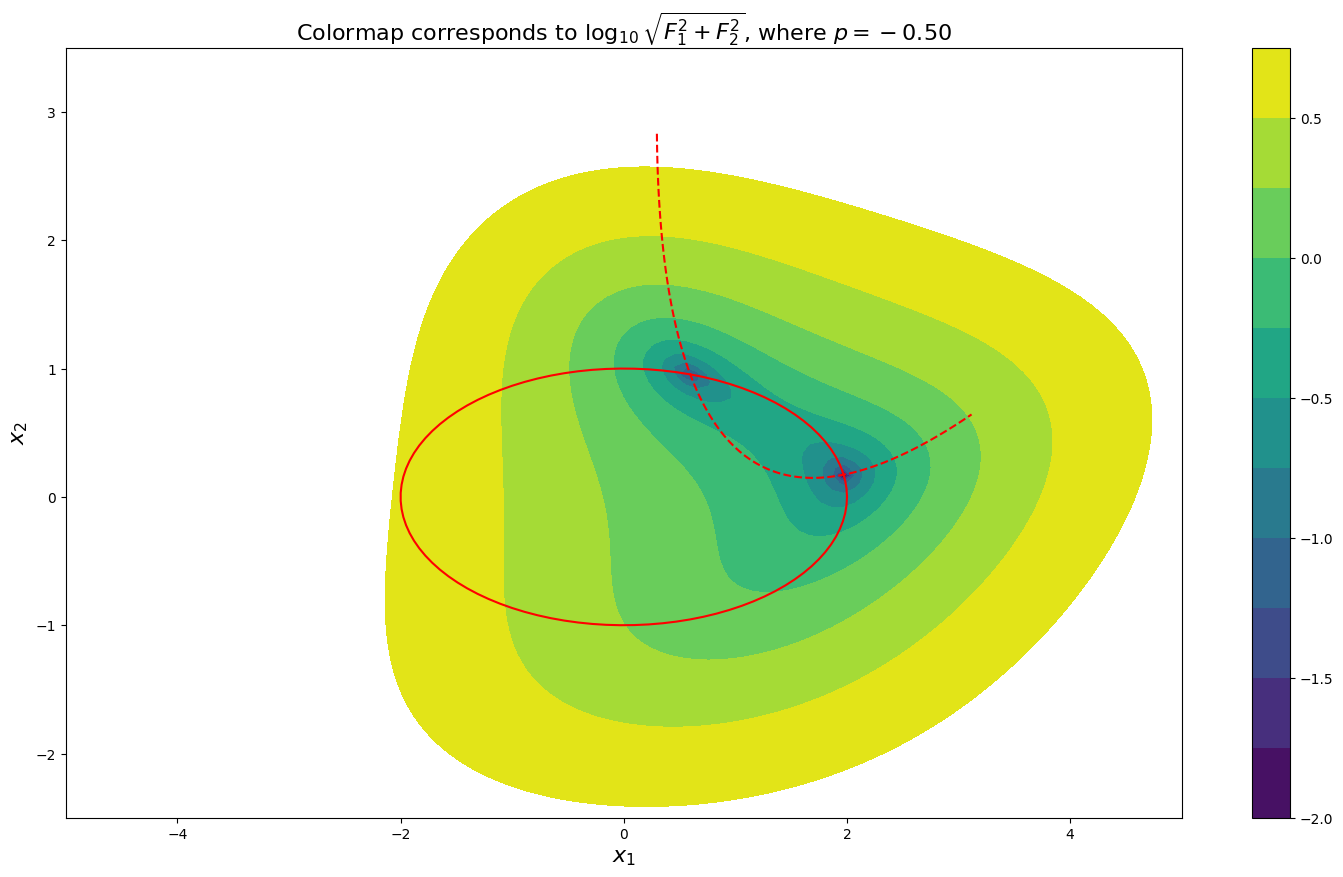

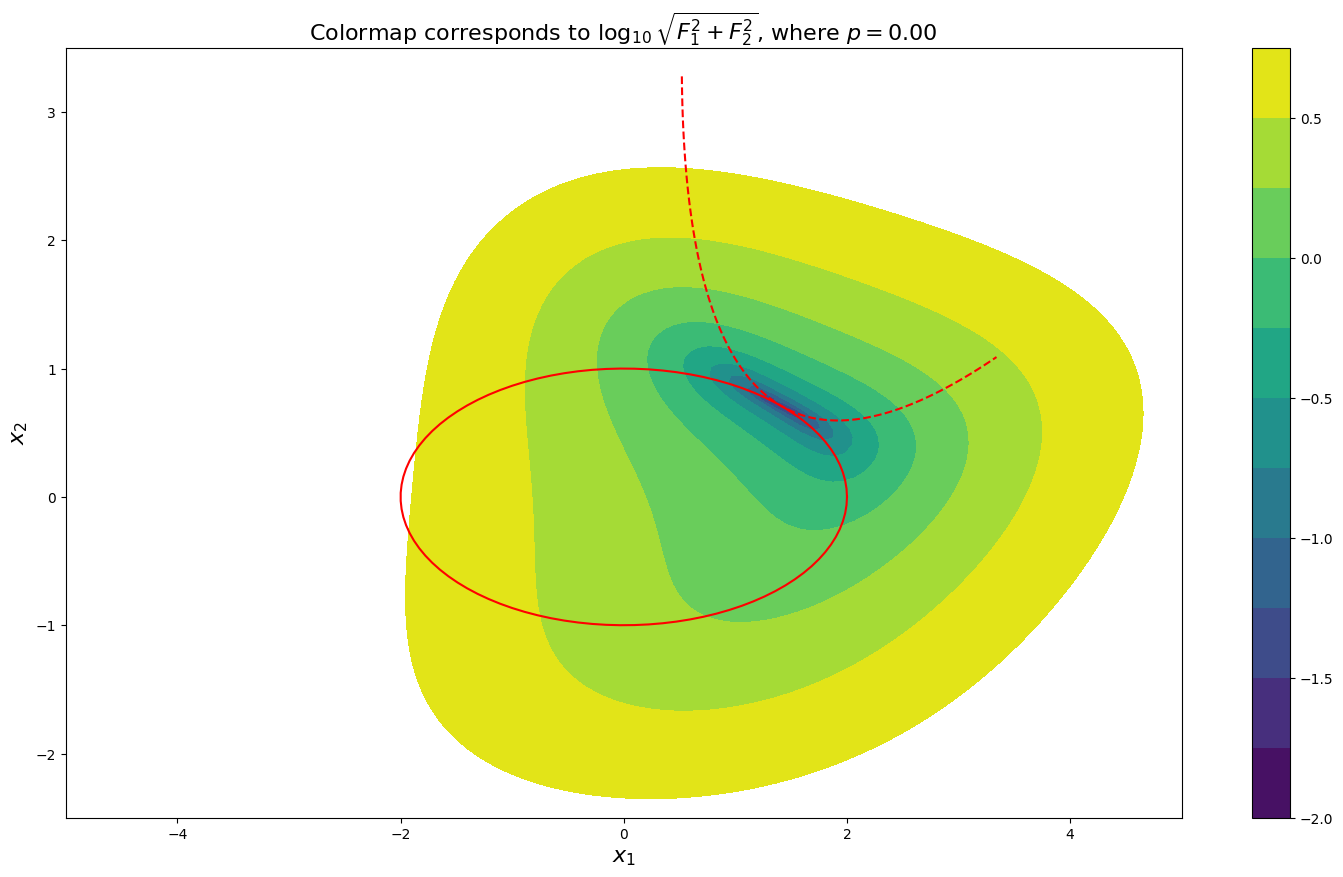

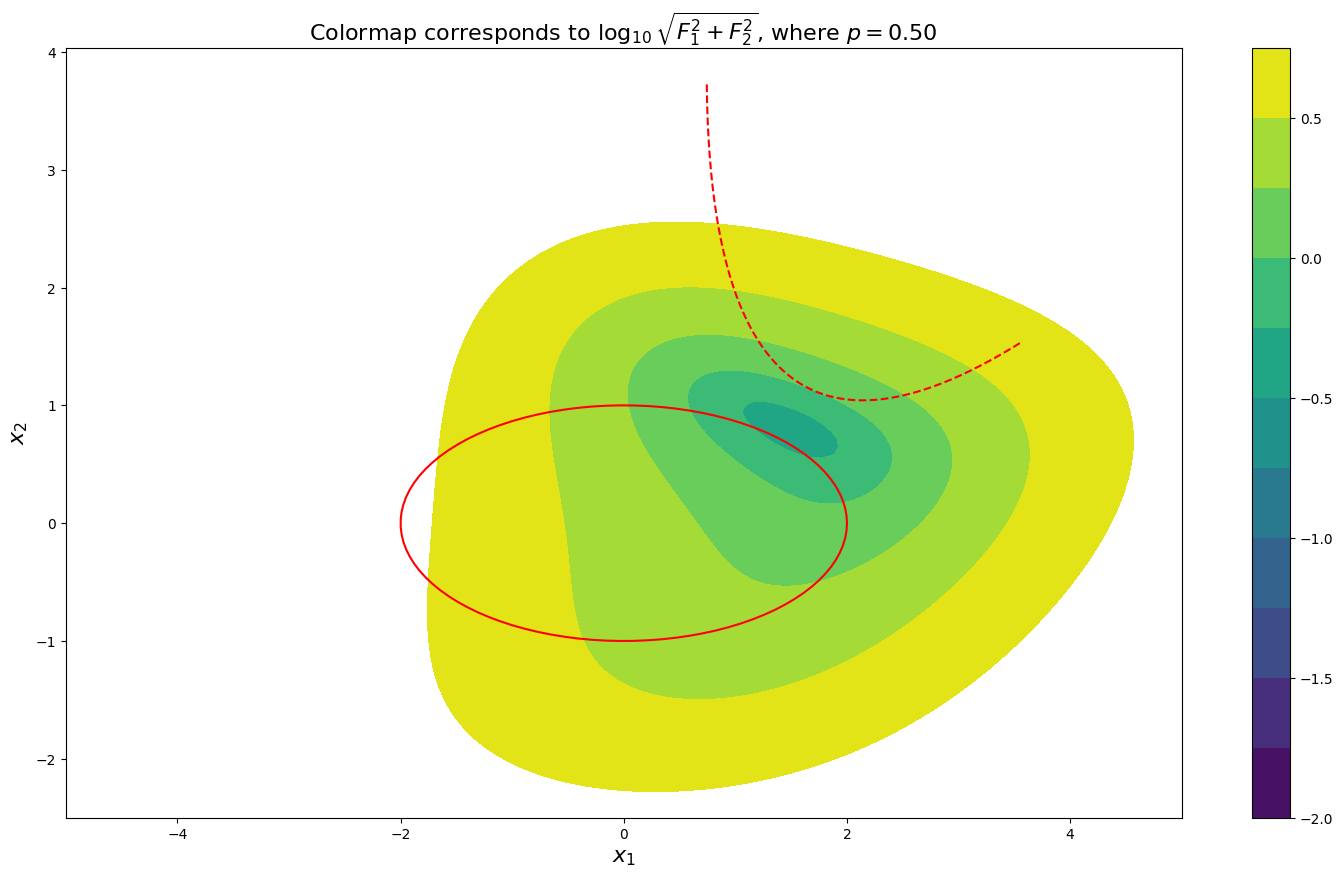

In [10]:
## Discussion question B.3

plt.figure(figsize=(12, 8))
#x0 = np.array([0, 0])
pVals = [-0.5, 0., 0.5]

# set up the components of F as described in equation (7) and the
# jacobian components; you also need to define z, n and t

# first component of F
F1 = lambda x: ((x[0] / 2) ** 2 ) + (x[1] ** 2) - 1
gradF1 = lambda x: np.array([ x[0]/2, 2 * x[1] ])


z = np.array([ ( 2 / np.sqrt(2) ), ( 1 / np.sqrt(2) ) ])
n = np.divide( gradF1(z), ( np.linalg.norm(gradF1(z)) ) )
t = np.array([ n[1], -n[0] ])
gradF2 = lambda x: n - ( t * (np.matmul(t, (x - z)) ) )
J1 = lambda x: np.array([ gradF1(x), gradF2(x) ])

# set up the initial guesses as defined in the pdf
x0Minus = z + ( 2 * (n - t) )
x0Plus = z + ( 2 * (n + t) )
initialGuesses = [x0Minus, x0Plus]



tol = 1e-8
maxit = 20
# print out the results as follows (or in a similar and readable way)
print('EXPLORE THE CONVERGENCE OF THE METHOD')
print('\n    p            x0                        success      iter            order                   x \n')
print('------------------------------------------------------------------------------------------------------------------')
for x0 in initialGuesses:
    for p in pVals:
        # for each p compute a different function F2, as we can only have x as
        # input so newton works
        F2 = lambda x: (np.matmul(n, (x - z)) - p - 0.5 * (np.matmul(t, (x - z)) ** 2))
        Fp = lambda x: np.array([F1(x), F2(x)])
        x, success, errEst, xHist = newton(Fp, J1, x0, tol=1e-6, maxit=1000)
        ord = order(x, xHist)

        # Align the outputs
        x0Print = np.array2string(x0, precision=6, separator=',', suppress_small=True)
        xPrint = np.array2string(x, precision=6, separator=',', suppress_small=True)
        successPrint = "True" if bool(success) else "False"

        print(f'{p:<12} {x0Print:<30} {successPrint:<12} {len(errEst):<12} {ord:<20.6f} {xPrint}')
        plotResidual_partB(p)



# for each value of p, you have to
# - print out all the information that you set up before
# - use plotResidual_partB to plot the sequence {x^(k)}



# **C. Iterative solution to system of linear equations**

In [11]:
# INPUT
# A                   NxN matrix
# b                   Nx1 right-hand side
# x0                  initial guess
# staticRichardson    boolean, True for static, False for dynamic
# tol                 (optional) desired tolerance
# maxIt               (optional) maximum number of iterations >>> dimension of the linear system
# alpha0              (optional) static parameter
#
# OUTPUT
# x             approximate solution (last computed)
# success       true means converged according to error estimator
# errEst        error estimate per iteration = norm(x(k+1)-x(k))
# xHist         array with intermediate solutions


# defaults: x(0) = 0, tolerance = 10−6, maximum iterations = dimension of the linear system.
# If α is not provided, it should be dynamically computed according to (9).

def richardson(A, b, staticRichardson, x0=np.zeros(len(b)), tol=1e-6, maxit=len(b)**2, alpha0=10.):
    #
    # we want to solve Ax = b
    # the method can be written as a fixed point iteration:
    #       x_{k+1} = G(x_{k})
    # where
    #       G(x_{k}) = x_{k} - alpha_{k} * r_{k} =
    #                = x_{k} - alpha_{k} * (b - A*x_{k})
    #

    # you can use an if statement to generate static and dynamic inside the
    # function and add inputs before the optional ones if you need something else

    # define r from tutorial C
    r = lambda x: b - np.matmul(A, x)  #residual

    if staticRichardson == True and alpha0 is not None:
        # true for static, the aplha is constant
        alpha = lambda x: alpha0
    else:
        # false for dynamic >>> implement dynamic Richardson, i.e. update alpha
        # for each iteration
        alpha = lambda x: ( np.matmul(r(x), r(x)) ) / ( np.matmul( np.transpose(r(x)), np.matmul(A, r(x)) ) )


    # define Gr from tutorial C
    Gr = lambda x: x + (alpha(x) * r(x))
    # implement fpIterator
    x, success, errEst, xHist = fpIterator(Gr,x0, tol, maxit)


    return x, success, errEst, xHist

In [12]:
#STATIC IMPLEMENTATION
# Test your implementation on the example problem (8). Check the third iteration: you should
# get x = [5/8, 1/4]

# set up the inputs
A = np.array([[2, -1], [-1, 2]])
b = np.array([1, 0])

alpha0 = 1/2

x, success, errEst, xHist = richardson(A, b, True, alpha0=1/2)


print( f"x: {x} \nsuccess: {success} \nerrEst: {errEst} \nxHist:\n {xHist}\n")
nIterations = len(errEst)
print("Number of iterations=", nIterations)
print(f"x after 3 iterations: {xHist[3]}")

x: [0.625  0.3125] 
success: False 
errEst: [0.5    0.25   0.125  0.0625] 
xHist:
 [[0.     0.    ]
 [0.5    0.    ]
 [0.5    0.25  ]
 [0.625  0.25  ]
 [0.625  0.3125]]

Number of iterations= 4
x after 3 iterations: [0.625 0.25 ]


<ipython-input-13-30007f04d09b>:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "go" (-> color='g'). The keyword argument will take precedence.
  plt.semilogy(alphas, iterations, 'go', color = 'purple')


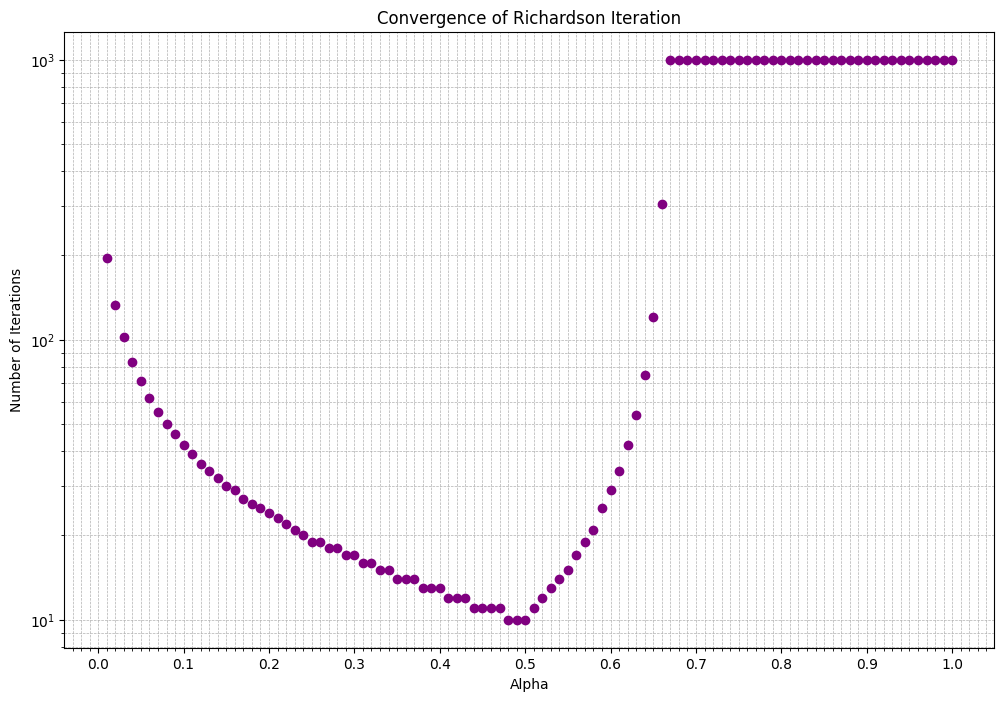

In [13]:
## Discussion question C.1

# set up the inputs of richardson() and consider creating a loop to vary alpha
# and saving the number of iterations (it should help to minimize errors)

# set up the inputs
A = np.array([[2, -1], [-1, 2]])
b = np.array([1, 0])

plt.figure(figsize=(12, 8))

# initalize iterations and alphas
iterations = np.zeros(100) # Store number of iterations for each alpha
alphas = np.zeros(100)

# implement richardson for each parameter value
for i in range(1,101):
    alphai = i / 100
    alphas[i-1] = alphai
    _, success, errEst, _ = richardson(A, b, True, tol=1e-3, maxit=int(1e3), alpha0=alphai)

    # store the number of iterations
    if success:
        iterations[i-1] = len(errEst)
    else:
        iterations[i-1] = 1000

# plot iterations as a function of alpha
plt.semilogy(alphas, iterations, 'go', color = 'purple')
plt.xlabel('Alpha')
plt.ylabel('Number of Iterations')
plt.title('Convergence of Richardson Iteration')


# Enable grid lines
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.minorticks_on()

# Customize grid lines for the x-axis (alphas)
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(0.1))
plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(0.01))

# Customize grid lines for the y-axis (iterations) for log scale
plt.gca().yaxis.set_major_locator(plt.LogLocator(base=10.0, numticks=10))
plt.gca().yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs='auto', numticks=10))
plt.gca().yaxis.set_minor_formatter(plt.NullFormatter())  # Optionally, turn off minor tick labels for y-axi


plt.show()



In [14]:
# testcase where you can check that the implementation of your function is correct.

#take a different 2 x 2 matrix with a different vector b
A = np.array([[5, -2], [-2, 5]])
b = np.array([1, 2])

xT, successT, errEstT, xHistT = richardson(A, b, True, maxit=20, alpha0=1/5)
print(xT, successT, errEstT, xHistT)
print('Number of iterations:' f'{len(errEstT)}')


xF, successF, errEstF, xHistF =x, success, errEst, xHist = richardson(A, b, False, maxit = 20)
print(xF, successF, errEstF, xHistF)
print('Number of iterations:' f'{len(errEstF)}')

[0.42857124 0.57142833] True [4.47213595e-01 1.78885438e-01 7.15541753e-02 2.86216701e-02
 1.14486680e-02 4.57946722e-03 1.83178689e-03 7.32714755e-04
 2.93085902e-04 1.17234361e-04 4.68937443e-05 1.87574977e-05
 7.50299909e-06 3.00119964e-06 1.20047985e-06 4.80191942e-07] [[0.         0.        ]
 [0.2        0.4       ]
 [0.36       0.48      ]
 [0.392      0.544     ]
 [0.4176     0.5568    ]
 [0.42272    0.56704   ]
 [0.426816   0.569088  ]
 [0.4276352  0.5707264 ]
 [0.42829056 0.57105408]
 [0.42842163 0.57131622]
 [0.42852649 0.57136865]
 [0.42854746 0.5714106 ]
 [0.42856424 0.57141898]
 [0.42856759 0.5714257 ]
 [0.42857028 0.57142704]
 [0.42857082 0.57142811]
 [0.42857124 0.57142833]]
Number of iterations:16
[0.42857128 0.57142859] True [6.57667052e-01 1.19575828e-01 4.22032333e-02 7.67331514e-03
 2.70822887e-03 4.92405250e-04 1.73790088e-04 3.15981979e-05
 1.11523051e-05 2.02769184e-06 7.15655944e-07] [[0.         0.        ]
 [0.29411765 0.58823529]
 [0.40106952 0.53475936]
 [0

In [15]:
# testcase where you can check that the implementation of your function is correct.

# take a 3 x 3 matrix
A = np.array([[4, 1, -2], [1, 5, 3], [-2, 3, 6]])
b = np.array([1, 2, 3])
print(len(b))

xT, successT, errEstT, xHistT = richardson(A, b, True, x0=np.array([0,0,0]), maxit=70, alpha0= 2 / ( 1+ (np.sqrt(3)+7) ))
print(xT, successT, errEstT, xHistT)
print('Number of iterations static:' f'{len(errEstT)}')
xF, successF, errEstF, xHistF =x, success, errEst, xHist = richardson(A, b, False, x0=np.array([0,0,0]), maxit = 70)
print(xF, successF, errEstF, xHistF)
print('Number of iterations dynamic:' f'{len(errEstF)}')

3
[ 0.7826081  -0.30434737  0.9130425 ] True [7.68935029e-01 5.72715743e-01 4.54679840e-01 3.61237251e-01
 2.87000611e-01 2.28020111e-01 1.81160489e-01 1.43930825e-01
 1.14352101e-01 9.08519973e-02 7.21813185e-02 5.73475861e-02
 4.55622827e-02 3.61989360e-02 2.87598182e-02 2.28494878e-02
 1.81537688e-02 1.44230508e-02 1.14590196e-02 9.10411626e-03
 7.23316091e-03 5.74669910e-03 4.56571491e-03 3.62743067e-03
 2.88196998e-03 2.28970633e-03 1.81915672e-03 1.44530814e-03
 1.14828787e-03 9.12307217e-04 7.24822126e-04 5.75866445e-04
 4.57522130e-04 3.63498344e-04 2.88797060e-04 2.29447378e-04
 1.82294444e-04 1.44831745e-04 1.15067875e-04 9.14206756e-05
 7.26331297e-05 5.77065472e-05 4.58474749e-05 3.64255193e-05
 2.89398372e-05 2.29925117e-05 1.82674004e-05 1.45133303e-05
 1.15307461e-05 9.16110249e-06 7.27843610e-06 5.78266995e-06
 4.59429351e-06 3.65013619e-06 2.90000936e-06 2.30403850e-06
 1.83054354e-06 1.45435489e-06 1.15547546e-06 9.18017706e-07] [[ 0.          0.          0.        ]


In [16]:
# DYNAMIC IMPLEMENTATION for A, b in (8)

# set up inputs
A = np.array([[2, -1], [-1, 2]])
b = np.array([1, 0])

x, success, errEst, xHist = richardson(A, b, False)

print( f"x= {x} \nsuccess: {success} \nerrEst: {errEst} \nxHist:\n {xHist}\n")
nIterations = len(errEst)
print("Number of iterations=", nIterations)

x= [0.625  0.3125] 
success: False 
errEst: [0.5    0.25   0.125  0.0625] 
xHist:
 [[0.     0.    ]
 [0.5    0.    ]
 [0.5    0.25  ]
 [0.625  0.25  ]
 [0.625  0.3125]]

Number of iterations= 4


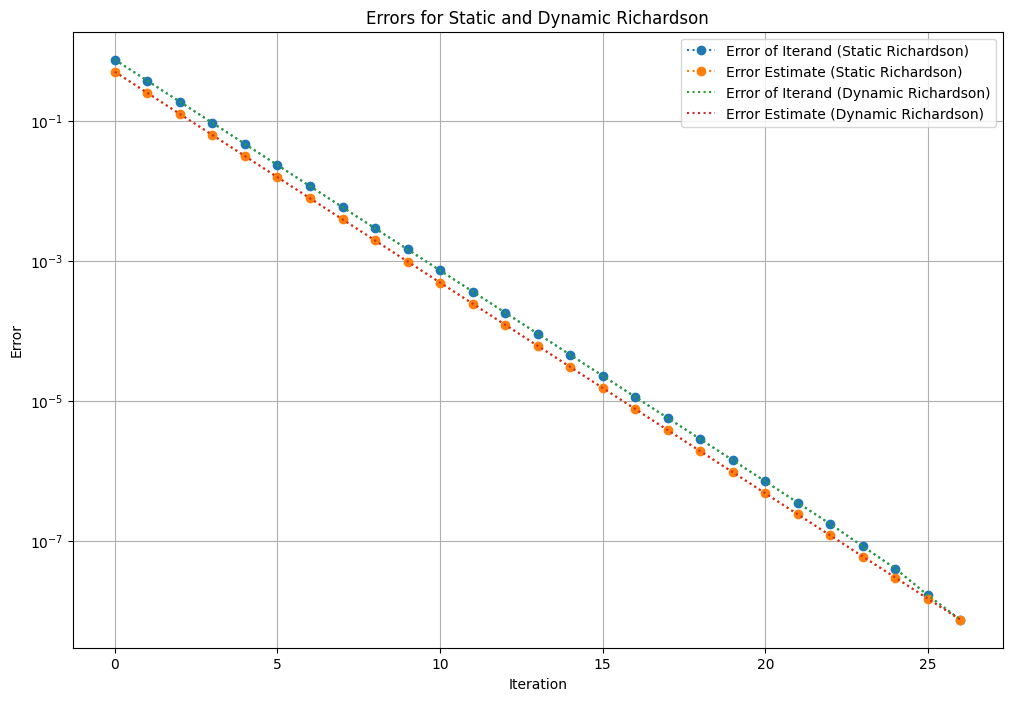

In [17]:
## Discussion question C.2 (a)-(b)

# set up the inputs for richardson() and x_star
# set up the optimal value of alpha

# find the root in both static and dynamic cases and plot the error estimates
# and the true errors

# set up inputs
A = np.array([[2, -1], [-1, 2]])
b = np.array([1, 0])

alphaOpt = 1/2

# compute the required elements for the errors:
# >>for error estimate we need errEstStatic(Dynamic)
# >>for error of iterand we need xStatic(Dynamic) and xHistStatic(Dynamic)
xStatic, _, errEstStatic, xHistStatic = richardson(A, b, True, alpha0=alphaOpt, tol=1e-8, maxit=int(1e3))
nIterationsStatic = len(errEstStatic)

xDynamic, _, errEstDynamic, xHistDynamic = richardson(A, b, False, tol=1e-8, maxit=int(1e3))
nIterationsDynamic = len(errEstDynamic)

errorIterandStatic = np.zeros(nIterationsStatic)
errorIterandDynamic = np.zeros(nIterationsDynamic)

# store the error of iterand for both static and dynamic
for k in range(nIterationsStatic):
    errorIterandStatic[k] = np.linalg.norm(xStatic - xHistStatic[k,:])
for k in range(nIterationsDynamic):
    errorIterandDynamic[k] = np.linalg.norm(xDynamic - xHistDynamic[k,:])


plt.figure(figsize=(12, 8))

# plot the error of iterand as a function of the number of iterations for static
plt.semilogy(range(nIterationsStatic), errorIterandStatic, marker= 'o', label='Error of Iterand (Static Richardson)', linestyle = 'dotted')
# plot the error estimate as a function of the number of iterations for static
plt.semilogy(range(nIterationsStatic), errEstStatic, marker= 'o', label='Error Estimate (Static Richardson)', linestyle = 'dotted')

# do the same as in the plots above, but for dynamic
plt.semilogy(range(nIterationsDynamic), errorIterandDynamic, label='Error of Iterand (Dynamic Richardson)',  linestyle = 'dotted')
plt.semilogy(range(nIterationsDynamic), errEstDynamic, label='Error Estimate (Dynamic Richardson)',  linestyle = 'dotted')

plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Errors for Static and Dynamic Richardson')
plt.grid(True)
plt.show()

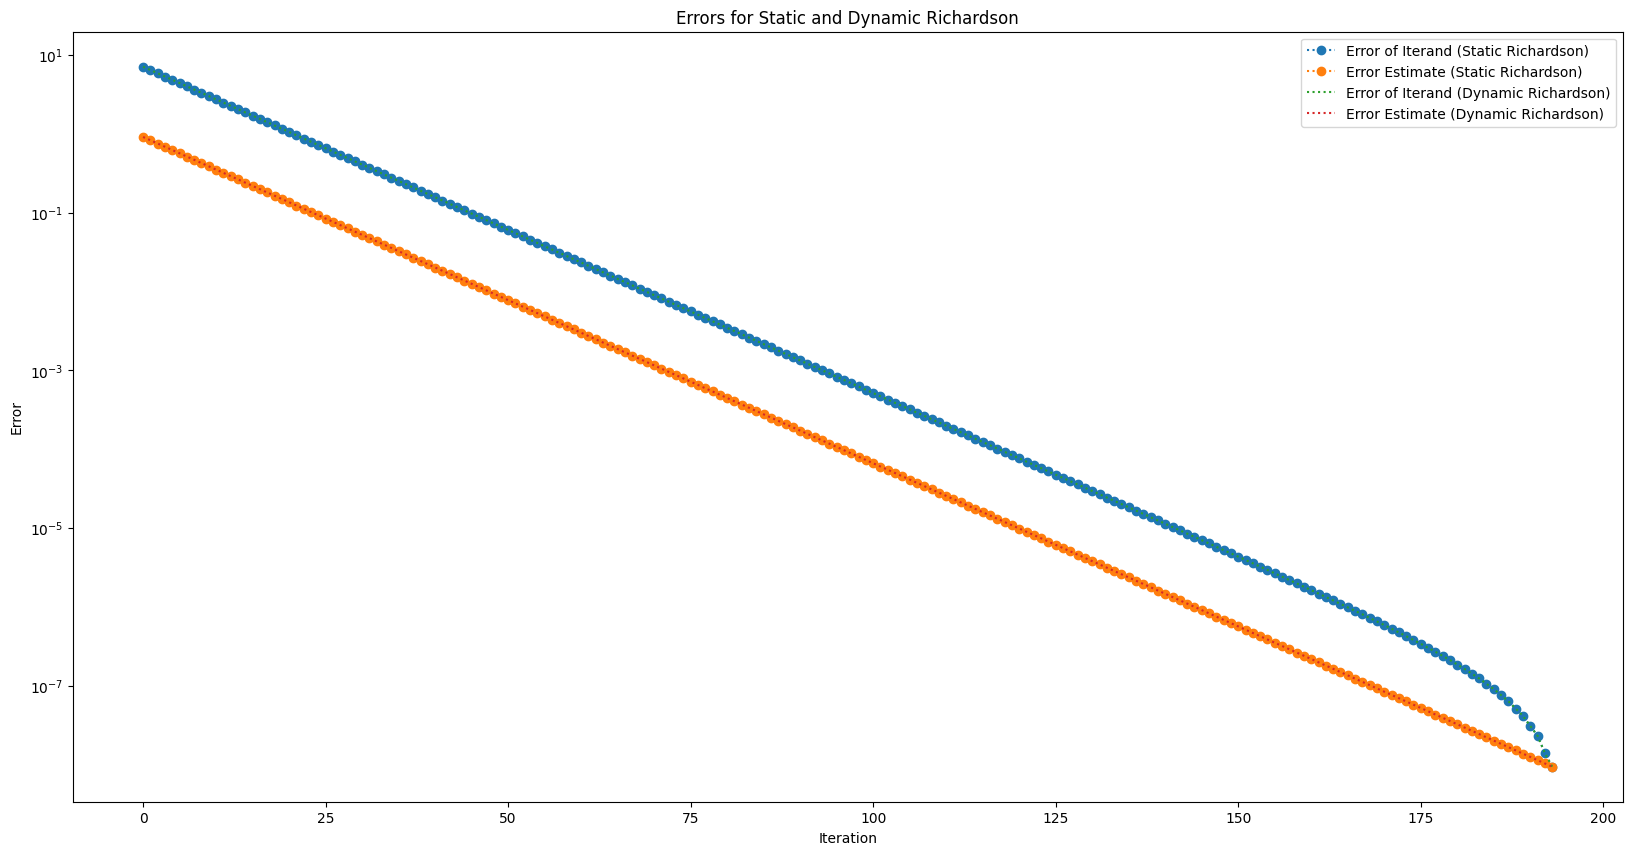

In [18]:
## Discussion question C.2 (c)-(d)

# repeat the previous exercise modifying the system of equations

# set up inputs
ANew = np.array([[1.1, -1], [-1, 1.1]])
b = np.array([1, 0])

alphaOpt = 10/11

# compute the required elements for the errors:
# >>for error estimate we need errEstStatic(Dynamic)
# >>for error of iterand we need xStatic(Dynamic) and xHistStatic(Dynamic)
xStatic, _, errEstStatic, xHistStatic = richardson(ANew, b, True, alpha0=alphaOpt, tol=1e-8, maxit=int(1e3))
nIterationsStatic = len(errEstStatic)

xDynamic, _, errEstDynamic, xHistDynamic = richardson(ANew, b, False, tol=1e-8, maxit=int(1e3))
nIterationsDynamic = len(errEstDynamic)


errorIterandStatic = np.zeros(nIterationsStatic)
errorIterandDynamic = np.zeros(nIterationsDynamic)

# store the error of iterand for both static and dynamic
for k in range(nIterationsStatic):
    errorIterandStatic[k] = np.linalg.norm(xStatic - xHistStatic[k,:])
for k in range(nIterationsDynamic):
    errorIterandDynamic[k] = np.linalg.norm(xDynamic - xHistDynamic[k,:])


plt.figure(figsize=(20, 10))

plt.semilogy(range(nIterationsStatic), errorIterandStatic, marker= 'o', label='Error of Iterand (Static Richardson)', linestyle = 'dotted')
plt.semilogy(range(nIterationsStatic), errEstStatic, marker= 'o', label='Error Estimate (Static Richardson)', linestyle = 'dotted')

plt.semilogy(range(nIterationsDynamic), errorIterandDynamic, label='Error of Iterand (Dynamic Richardson)',linestyle = 'dotted')
plt.semilogy(range(nIterationsDynamic), errEstDynamic, label='Error Estimate (Dynamic Richardson)', linestyle = 'dotted')

plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Errors for Static and Dynamic Richardson')

plt.show()

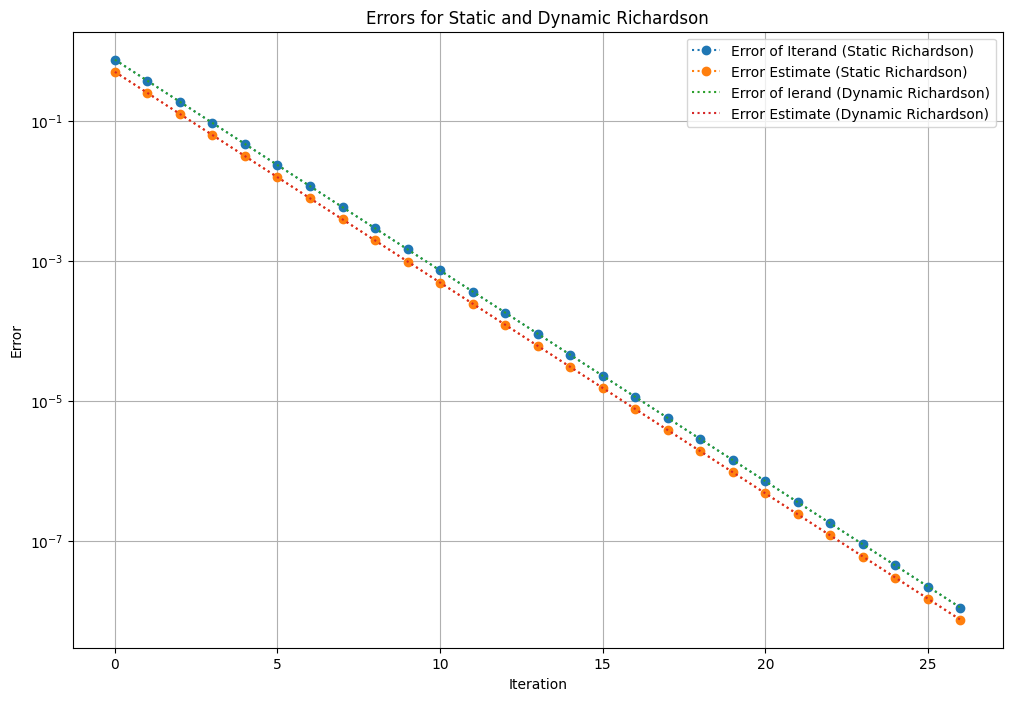

In [19]:
## Repeat the plots above, but using xStar = np.linalg.solve(A, b), the ecact
# root instead of the approximation we found

# set up inputs
A = np.array([[2, -1], [-1, 2]])
b = np.array([1, 0])

alphaOpt = 1/2


#solve the system to find the actual root
xStar = np.linalg.solve(A, b)

xStatic, _, errEstStatic, xHistStatic = richardson(A, b, True, alpha0=alphaOpt, tol=1e-8, maxit=int(1e3))
nIterationsStatic = len(errEstStatic)

xDynamic, _, errEstDynamic, xHistDynamic = richardson(A, b, False, tol=1e-8, maxit=int(1e3))
nIterationsDynamic = len(errEstDynamic)

errorIterandStatic = np.zeros(nIterationsStatic)
errorIterandDynamic = np.zeros(nIterationsDynamic)

for k in range(nIterationsStatic):
    errorIterandStatic[k] = np.linalg.norm(xStar - xHistStatic[k,:])
for k in range(nIterationsDynamic):
    errorIterandDynamic[k] = np.linalg.norm(xStar - xHistDynamic[k,:])


plt.figure(figsize=(12, 8))

plt.semilogy(range(nIterationsStatic), errorIterandStatic, marker= 'o', label='Error of Iterand (Static Richardson)', linestyle = 'dotted')
plt.semilogy(range(nIterationsStatic), errEstStatic, marker= 'o', label='Error Estimate (Static Richardson)', linestyle = 'dotted')

plt.semilogy(range(nIterationsDynamic), errorIterandDynamic, label='Error of Ierand (Dynamic Richardson)',  linestyle = 'dotted')
plt.semilogy(range(nIterationsDynamic), errEstDynamic, label='Error Estimate (Dynamic Richardson)',  linestyle = 'dotted')

plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Errors for Static and Dynamic Richardson')
plt.grid(True)
plt.show()

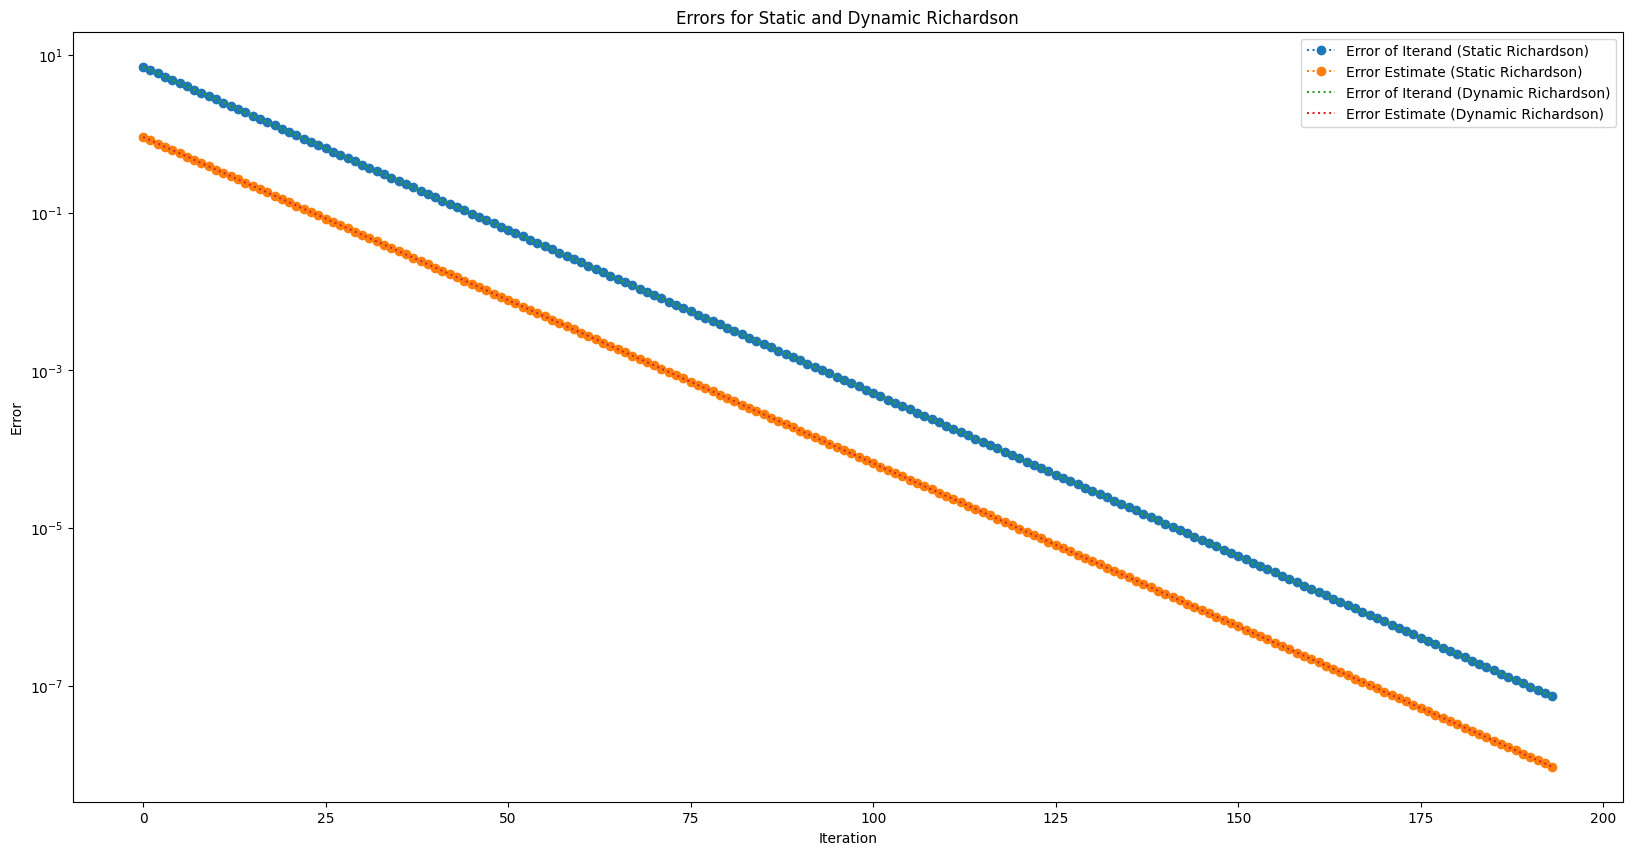

In [20]:
## Repeat the plots above, but using xStar = np.linalg.solve(A, b), the ecact
# root instead of the approximation we found

# set up inputs
ANew = np.array([[1.1, -1], [-1, 1.1]])
b = np.array([1, 0])

alphaOpt = 10/11


xStar = np.linalg.solve(ANew, b)

xStatic, _, errEstStatic, xHistStatic = richardson(ANew, b, True, alpha0=alphaOpt, tol=1e-8, maxit=int(1e3))
nIterationsStatic = len(errEstStatic)

xDynamic, _, errEstDynamic, xHistDynamic = richardson(ANew, b, False, tol=1e-8, maxit=int(1e3))
nIterationsDynamic = len(errEstDynamic)


errorIterandStatic = np.zeros(nIterationsStatic)
errorIterandDynamic = np.zeros(nIterationsDynamic)

for k in range(nIterationsStatic):
    errorIterandStatic[k] = np.linalg.norm(xStar - xHistStatic[k,:])
for k in range(nIterationsDynamic):
    errorIterandDynamic[k] = np.linalg.norm(xStar - xHistDynamic[k,:])


plt.figure(figsize=(20, 10))

plt.semilogy(range(nIterationsStatic), errorIterandStatic, marker= 'o', label='Error of Iterand (Static Richardson)', linestyle = 'dotted')
plt.semilogy(range(nIterationsStatic), errEstStatic, marker= 'o', label='Error Estimate (Static Richardson)', linestyle = 'dotted')

plt.semilogy(range(nIterationsDynamic), errorIterandDynamic, label='Error of Iterand (Dynamic Richardson)',linestyle = 'dotted')
plt.semilogy(range(nIterationsDynamic), errEstDynamic, label='Error Estimate (Dynamic Richardson)', linestyle = 'dotted')

plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Errors for Static and Dynamic Richardson')
#plt.grid(True)
plt.show()